In [2]:
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import json
from types import SimpleNamespace
import pandas as pd
import matplotlib as mpl

sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

import sys
sys.path.append('../../code/6_CRM')
from CRM import CRM
from CRM_utils import has_converged

In [3]:
git_folder = Path('../..')
code_folder = git_folder / 'code' / '7_CRM'
results_folder = git_folder / 'simulation_results' / 'n_cs_vs_K_parameter_swipe'
figure_folder = git_folder / 'figures' / '7_CRM'
figure_folder.mkdir(parents=True, exist_ok=True)


run = '20251216-120719'
fn_abundances = f'{run}_data.npz'
data = np.load(results_folder / fn_abundances)

fn_args = f'{run}_args.txt'

with open(results_folder / fn_args, 'r') as f:
    args_dict = json.load(f)
args = SimpleNamespace(**args_dict)




In [4]:
final_abundance_data = data['all_N_final']
final_resource_data = data['all_R_final']


In [5]:
final_abundance_matrix = np.zeros((args.N_cs, args.N_K_std, args.N_Csp, args.iterations, 4))
all_C = {}
counter = 0
for i in range(args.N_cs):
    for j in range(args.N_K_std):
        for k in range(args.N_Csp):
            final_abundance_matrix[i,j,k,:,:] = final_abundance_data[counter]
            counter += 1
            # for l in range(args.iterations):
            #     key = (i, j, k, l)
            #     all_C[key] = data[f'C_{counter}_{l}'] 

In [6]:
if False:
    all_C = {}
    all_D = {}
    for x, d in data.items():
        if 'C_' in x:
            all_C[x] = d
        if 'D_' in x:
            all_D[x] = d

In [7]:
data['all_N_final'].shape

(528, 50, 4)

In [8]:
richness_matrix = (final_abundance_matrix > 1e-6).sum(axis=4).mean(axis=3)
median_richness = np.median((final_abundance_matrix > 1e-6).sum(axis=4), axis=3)

In [9]:
richness_matrix_full = (final_abundance_matrix > 1e-6).sum(axis=4)

# Make variable lists from args


In [10]:

n_cs_arr = np.linspace(args.cs_min, args.cs_max, num=args.N_cs, dtype=int, endpoint = True)
K_std_arr = np.linspace(args.K_std_min, args.K_std_max, num = args.N_K_std, endpoint = True)
c_arr = np.linspace(args.csp_min, args.csp_max, num = args.N_Csp, endpoint = True)


In [11]:
final_abundance_matrix.shape

(16, 11, 3, 50, 4)

In [12]:
k = 0
for x in data.keys():
    if 'D_' in x:
        k+=1
print(k)

26400


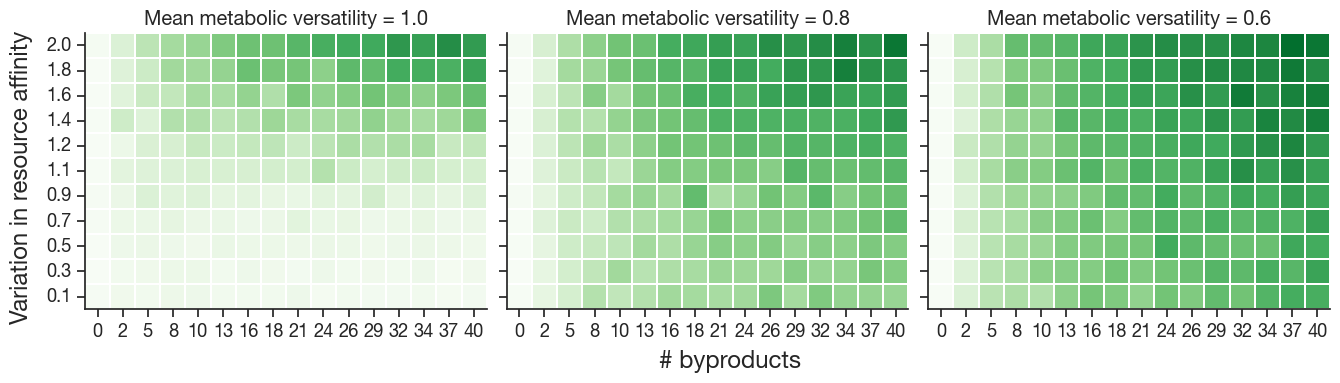

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(args.N_Csp):
    ax = axes[i]
    ax.set_title(f'Mean metabolic versatility = {1 - c_arr[i]:.1f}')
    # if i == args.N_Csp - 1:
    #     cbar = True
    # else:
    cbar = False
    sns.heatmap(richness_matrix[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = cbar,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='w', linewidths=0.1, annot=False, square=True)
    # )
fig.supylabel(r'Variation in resource affinity')
fig.supxlabel('# byproducts')
plt.subplots_adjust(left=0.07, wspace = 0.05, bottom = 0.15)
sns.despine(fig=fig, left=False, bottom=False)
# plt.title('Richness on single carbon source with 4 species community')
plt.savefig(figure_folder / '4_species_assembly_heatmap.pdf', dpi=300, bbox_inches='tight')

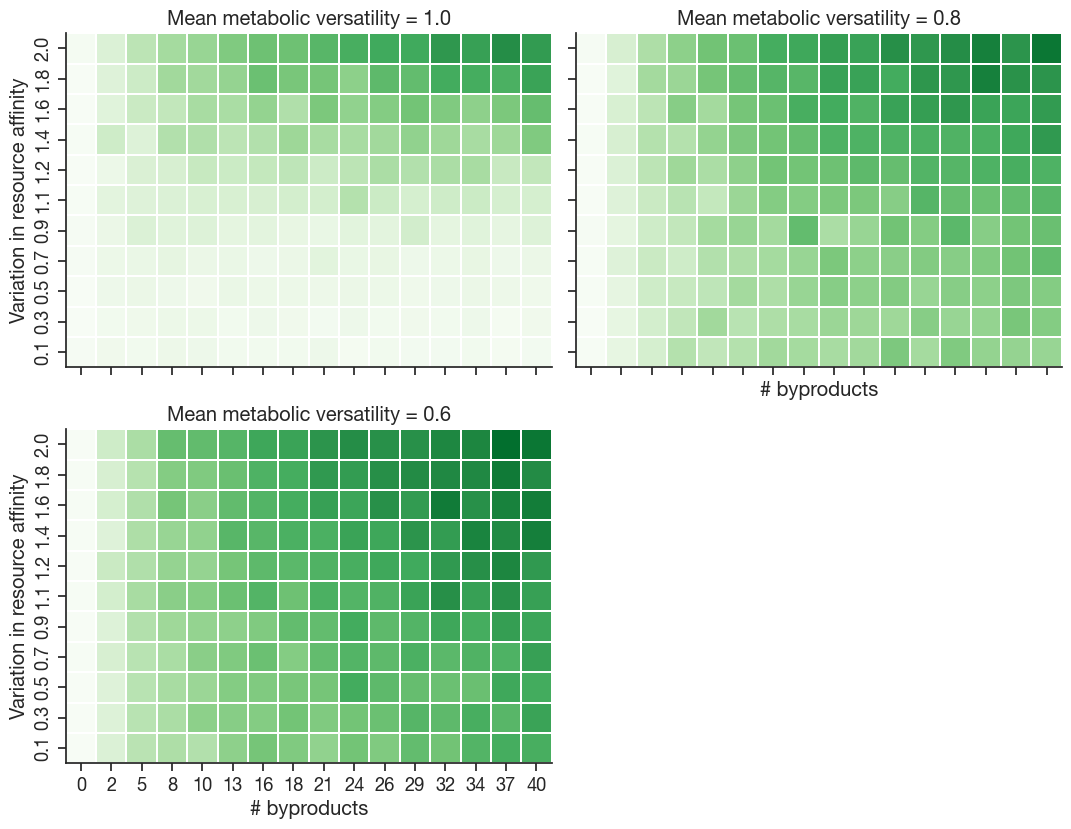

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()
for i in range(args.N_Csp):
    ax = axes[i]
    ax.set_title(f'Mean metabolic versatility = {1 - c_arr[i]:.1f}')
    # if i == args.N_Csp - 1:
    #     cbar = True
    # else:
    cbar = False
    sns.heatmap(richness_matrix[:,::-1,i].T, 
                yticklabels=[f'{x:.1f}' for x in K_std_arr][::-1],
                cmap='Greens',
                cbar = cbar,
                cbar_kws={'label':'Mean richness'}, 
                xticklabels = n_cs_arr-1,
                vmin = 1, vmax = 4, ax = ax, linecolor='w', linewidths=0.1, annot=False, square=True)
    # )
axes[0].set_ylabel('Variation in resource affinity')
axes[2].set_ylabel('Variation in resource affinity')
axes[1].set_xlabel('# byproducts')
axes[2].set_xlabel('# byproducts')
# fig.supylabel('Variation in resource affinity', x = 0.01)
# fig.supxlabel('# byproducts')
axes[-1].remove()
plt.subplots_adjust(left=0.07, wspace = 0.05, bottom = 0, hspace=-0.4)
sns.despine(fig=fig, left=False, bottom=False)
# plt.title('Richness on single carbon source with 4 species community')
plt.savefig(figure_folder / '4_species_assembly_heatmap_square.pdf', dpi=300, bbox_inches='tight')

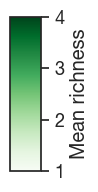

In [15]:

# Set up normalization and colormap to match your heatmap
vmin, vmax = 1, 4
cmap = 'Greens'
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# Create a new figure for just the colorbar
fig, ax = plt.subplots(figsize=(0.4, 2))
cbar = plt.colorbar(sm, cax=ax)
cbar.set_label('Mean richness')
plt.savefig(figure_folder / '4_species_assembly_colorbar.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot an example

36


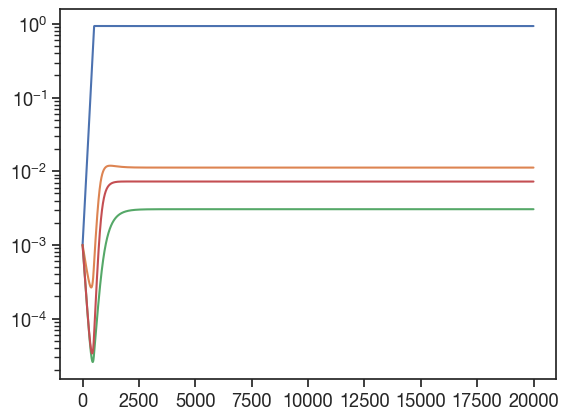

In [16]:
max_time = 2000
initial_abundance = 1e-3


dt = 0.1
method = 'LSODA'
initial_c_conc = 10
new_data = []
N0 = np.ones(4) * initial_abundance
dilution_rate = 0.1
g = 0.1

i = 500
# iteri +=1
iteri = 36
print(iteri)
C = data[f'C_{i}_{iteri}']
D = data[f'D_{i}_{iteri}']
K = data[f'K_{i}_{iteri}']
n_cs = C.shape[1]

R0 = np.zeros(n_cs)
R0[0] = initial_c_conc
l = args.leakage
# if C[:, j].max()*g < 2*dilution_rate:
    
c = CRM(4, n_cs, C = C, D=D, dilution_rate=0.1, l=l, K=K, atol=1e-9, rtol=1e-9, g=0.1)
# sol = c.run(max_time, N0, R0, dt=dt, method=method, max_calls=1e5)
try:
    sol = c.run(max_time, N0.copy(), R0.copy(), dt=dt, method=method, max_calls=1e5)
except (RuntimeError, ValueError):
    print('Error: ', i, j)
#     new_data.append({'final_abundance': np.nan, 'final_resources': np.nan, 'resource_no': j, 'key': sdata['key'], 'success': False})
# else:
#     if sol.success:
#         new_data.append({'final_abundance': c.N[-1, :], 'final_resources': c.R[-1, :],  'resource_no': j, 'key': sdata['key'], 'success': sol.success, 
#                                     'converged': has_converged(c.N, 1e-7)})
        

plt.semilogy(c.N)

In [17]:
palette = sns.color_palette('tab10', n_colors=10)

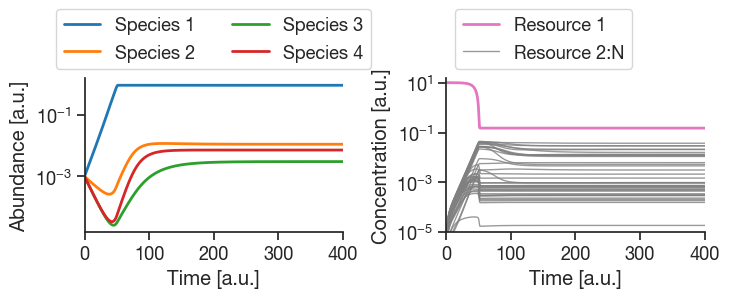

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(8, 2))
N = sol['y'][:4]

N[N <= 1e-7] = np.nan
R = sol['y'][4:]
axes[0].plot(sol.t, N[0], label = 'Species 1', c = palette[0], lw = 2)
axes[0].plot(sol.t, N[1], label = 'Species 2', c = palette[1], lw = 2)
axes[0].plot(sol.t, N[2], label = 'Species 3', c = palette[2], lw = 2)
axes[0].plot(sol.t, N[3], label = 'Species 4', c = palette[3], lw = 2)
# sns.lineplot(dc.N, ax=axes[0])
# sns.lineplot(data=c.R, ax=axes[1])
axes[1].plot(sol.t, R[0], label = 'Resource 1', c = palette[6], lw = 2)
axes[1].plot(sol.t, R[1:].T, label = 'Resource 2:N', c = 'grey', lw = 1, alpha = 0.8)
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlim(0, 400)
    ax.set_xlabel('Time [a.u.]')
axes[0].set_ylabel('Abundance [a.u.]')
axes[0].legend(frameon=True, ncol=2, loc='lower center', bbox_to_anchor=(0.5, 1.0))
axes[1].set_ylabel('Concentration [a.u.]')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles[:2], labels[:2], frameon=True, ncol=1, loc='lower left', bbox_to_anchor=(0, 1.0))
# axes[1].legend(frameon=True, ncol=1, loc='lower center', bbox_to_anchor=(0.5, 1.0))
axes[1].set_ylim(1e-5, 15)
# fig.supxlabel('Time [a.u.]', y = -0.1)
plt.subplots_adjust(wspace=0.4)

sns.despine()
plt.savefig(figure_folder / '4_species_assembly_example.pdf', dpi=300, bbox_inches='tight')

# Plot distributions


0.0
0.0
0.0044444444444444444


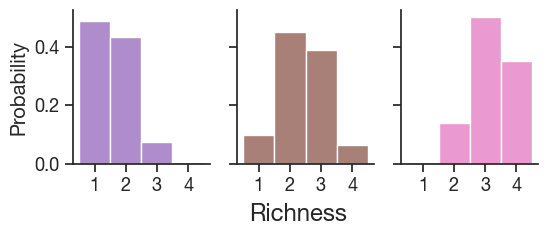

In [32]:
# Niche breadth = 0.8
i = 1
# Section 1 - 2-8 byproducts, <= 0.5 rsource affinity variation
r1 = richness_matrix_full[1:4, :3, i, :]

# Section 2 - 18-24 byproducts, <= 1.2 rsource affinity variation
r2 = richness_matrix_full[7:10, 4:7, i, :]

# Section 3 34- 40 byproducts, <= 2.0 rsource affinity variation
r3 = richness_matrix_full[13:, 8:11, i, :]

fig, axes = plt.subplots(1, 3, figsize=(6,2), sharey=True, sharex = True)
axes = axes.flatten()
for i, (ax, r) in enumerate(zip(axes, [r1, r2, r3])):
    print(np.sum(r.flatten()==0)/len(r.flatten()))
    dist_r = [x for x in r.flatten() if x!=0]
    sns.histplot(dist_r, bins=np.arange(0.5, 5.5, 1), discrete=True, stat='probability', 
                color = palette[4+i],
                # width = 1,
                ax=ax)
    # print(r)
    # sns.kdeplot(r.flatten(), bw_adjust=0.5, fill=True, common_norm=False, alpha=0.7, ax=ax)
    # ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Probability')
    ax.set_xticks([1,2,3,4])
fig.supxlabel('Richness', y = -0.2)
sns.despine()
plt.savefig(figure_folder / '4_species_assembly_richness_histograms.pdf', dpi=300, bbox_inches='tight')